## Dependencies & Environment Setup

### Imports

In [1]:
import os
import re
import sys
import emoji
import string
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from deep_translator import GoogleTranslator
from langdetect import detect, LangDetectException
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

try:
    import fasttext
except Exception:
    fasttext = None

try:
    import urllib.request
except Exception:
    pass

### Project Root Detection

In [2]:
# Find the project root by walking upward until requirements.txt is found
_project_root = Path.cwd().resolve()
for parent in [_project_root, *_project_root.parents]:
    if (parent / "requirements.txt").exists():
        _project_root = parent
        break
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))


### Path Constants

In [3]:
PROJECT_ROOT = _project_root
DATASET_DIR = PROJECT_ROOT / "data" / "raw"
RESULT_DIR = PROJECT_ROOT / "results"
TRANSLATED_CSV_DIR = RESULT_DIR / "translated"
CLEANED_CSV_DIR = PROJECT_ROOT / "data" / "interim" / "cleaned"
FASTTEXT_MODEL_DIR = PROJECT_ROOT / "models" / "fasttext"
FASTTEXT_MODEL_NAME = "lid.176.bin"
FASTTEXT_MODEL_PATH = FASTTEXT_MODEL_DIR / FASTTEXT_MODEL_NAME

# Raw per-app review csv locations
DATASET_PATH_DICT = {
    "bKash": DATASET_DIR / "bkash_bd_reviews.csv",
    "Nagad": DATASET_DIR / "nagad_bd_reviews.csv",
    "Rocket": DATASET_DIR / "rocket_bd_reviews.csv",
}

REQUIRED_RAW_CSV_COLUMNS = [
    "app_name", "review_id", "review_date", "rating", "review_text",
    "thumbs_up_count", "app_version"
]
REQUIRED_MASTER_CSV_COLUMNS = [
    "app_name", "review_id", "review_date", "rating", "review_text",
    "review_text_clean", "thumbs_up_count", "app_version"
]
REQUIRED_SCORED_MASTER_CSV_COLUMNS = REQUIRED_MASTER_CSV_COLUMNS + [
    "sentiment_score", "gap_score", "mismatch_label"
]

# LDA configuration constants
STOPWORDS_FOR_LDA = {"review", "app", "bkash", "nagad", "rocket", "service", "problem", "issue", "error"}
LDA_MIN_THRESHOLD = 5
LDA_TOPIC_NUM = 5
LDA_TOPWORD_NUM = 10

### Path Related Helpers

In [4]:
def get_run_paths(only_english: bool = False) -> dict:
    """Return output directories for the current run mode."""
    mode_name = "only_english" if only_english else "bangla_english"
    result_dir = PROJECT_ROOT / "results" / mode_name
    translated_dir = result_dir / "translated"
    cleaned_dir = PROJECT_ROOT / "data" / "interim" / "cleaned" / mode_name
    master_csv_path = result_dir / "master_bd_reviews.csv"
    scored_master_csv_path = result_dir / "master_bd_reviews_scored.csv"
    return {
        "mode_name": mode_name,
        "result_dir": result_dir,
        "translated_dir": translated_dir,
        "cleaned_dir": cleaned_dir,
        "master_csv_path": master_csv_path,
        "scored_master_csv_path": scored_master_csv_path,
    }


def ensure_dirs(only_english: bool = False):
    """Create the output folders used by this notebook, without relying on project modules."""
    run_paths = get_run_paths(only_english=only_english)
    run_paths["result_dir"].mkdir(parents=True, exist_ok=True)
    run_paths["translated_dir"].mkdir(parents=True, exist_ok=True)
    run_paths["cleaned_dir"].mkdir(parents=True, exist_ok=True)

## Dictionaries & Normalization Config

In [5]:
# Shared dictionaries for debugging clarity
PRE_TRANSLATION_DICT = {
    'aap': 'app', 'absulatlly': 'absolutely', 'acaunt': 'account', 'ae': 'app',
    'agant': 'agent', 'akti': 'a', 'amezing': 'amazing', 'ami': 'i', 'amr': 'my',
    'amy': 'i', 'aop': 'app', 'ap': 'app', 'apc': 'app', 'apk': 'app', 'apos': 'apps',
    'appa': 'apps', 'appd': 'app', 'appe': 'app', 'appy': 'app', 'aps': 'app',
    'apss': 'app', 'argent': 'urgent', 'arzent': 'urgent', 'ata': 'this', 'ato': 'very',
    'balo': 'good', 'bari': 'very', 'batter': 'better', 'beawtifull': 'beautiful',
    'bebohar kore': 'use', 'beri': 'very', 'bhalo': 'good', 'bikas': 'bkash',
    'bikash': 'bkash', 'bks': 'bkash', 'bksh': 'bkash', 'bonas': 'bonus',
    'bossor': 'year', 'bs': 'bullshit', 'chai': 'want', 'chalu': 'start',
    'cod': 'code', 'commisiion': 'commission', 'den na': 'does not give',
    'dey na': 'does not give', 'dipertment': 'department', 'distap': 'disturb',
    'doog': 'good', 'eazy': 'easy', 'ebong': 'and', 'et': 'it', 'experence': 'experience',
    'f': 'app', 'faltu': 'useless', 'famelly': 'family', 'faul': 'useless',
    'fiks': 'fix', 'forbikas': 'for bkash', 'fst': 'fast', 'full fill': 'fulfil',
    'g': 'good', 'gd': 'good', 'god': 'good', 'godd': 'good', 'goid': 'good',
    'goo': 'good', 'goob': 'good', 'good serve': 'good service', 'goods': 'good',
    'goody': 'good', 'goof': 'good', 'goog': 'good', 'goot': 'good', 'greet': 'great',
    'gud': 'good', 'hamfull': 'harmful', 'help ful': 'helpful', 'help full': 'helpful',
    'helped full': 'helpful', 'helpfuul': 'helpful', 'helpul': 'helpful', 'hepi': 'happy',
    'hotasa jonok': 'disappointing', 'ken': 'why', 'khob': 'very', 'khub': 'very',
    'khuv': 'very', 'kintu': 'but', 'korte parci na': 'i can not', 'korte parina': 'i can not',
    'korun': 'do', 'kurte paachhe ne': 'can not do', 'lakte se': 'feel', 'leading': 'loading',
    'lenden': 'transactions', 'lendener jonno': 'for transations', 'lon': 'loan',
    'lone': 'loan', 'loun': 'loan', 'lov': 'love', 'lugin': 'login', 'mi': 'my',
    'mobil': 'mobile', 'na': 'no/not', 'nace': 'nice', 'nacs': 'nice', 'nagod': 'nagad',
    'nah': 'no/not', 'naic': 'nice', 'naice': 'nice', 'naiec': 'nice', 'naies': 'nice',
    'nais': 'nice', 'nar bar': 'everytime', 'nc': 'nice', 'neis': 'nice', 'netay': 'get',
    'nic': 'nice', 'niceapp': 'nice app', 'nicee': 'nice', 'nices': 'nice', 'nich': 'nice',
    'nicr': 'nice', 'nieas': 'nice', 'niec': 'nice', 'nihc': 'nice', 'nise': 'nice',
    'nive': 'nice', 'noce': 'nice', 'nuch': 'nice', 'onak': 'very', 'onek': 'very',
    'onek din': 'many days', 'onk': 'very', 'outhe': 'other', 'paina': "can't get",
    'parmeshon': 'permission', 'parson': 'person', 'pls': 'please', 'por': 'after',
    'prblm': 'problem', 'rael': 'real', 'sait': 'site', 'sand': 'send', 'sapot': 'support',
    'sar': 'sir', 'scame': 'scam', 'seaport': 'support', 'servar': 'server', 'sheba': 'service',
    'shlw': 'slow', 'slove': 'solve', 'solow': 'slow', 'sonetimes': 'sometimes', 'soo': 'so',
    'sudi': 'bad', 'sundor': 'nice', 'supar': 'super', 'suppar': 'super', 'supper': 'super',
    'suprot': 'support', 'survice': 'service', 'taki': 'thaki', 'teke': 'for', 'theif': 'thief',
    'thier': 'there', 'thku': 'thank you', 'thx': 'thanks', 'tik': 'fix', 'tnx': 'thanks',
    'transection': 'transaction', 'trast': 'trust', 'use full': 'useful', 'use less': 'useless',
    'v.goods': 'very good', 'vai': 'brother', 'valo': 'good', 'valobasa': 'love', 'vare': 'very',
    'varey': 'very', 'vary': 'very', 'veery': 'very', 'veri': 'very', 'verry': 'very',
    'very bed': 'very bad', 'very safety': 'very safe', 'vhalo': 'good', 'vi': 'brother',
    'via': 'brother', 'vire': 'very', 'viry': 'very', 'weel': 'well', 'welcum': 'welcome',
    'whay': 'why', 'wonder full': 'wonderful',
    'আপ': 'app', 'আবরেট': 'update', 'এফ': 'app', 'ওক': 'ok', 'ওটিবি': 'otp',
    'কেন': 'why', 'গুট': 'good', 'চুমুতকা': 'nice', 'জামেলা': 'hassle', 'টাকা': 'bdt',
    'নাইচ': 'nice', 'নাইছ': 'nice', 'নাইস': 'nice', 'নাববার': 'number', 'বাঝে': 'bad',
    'বালের': 'useless', 'বালের এপ': 'useless app', 'বালো': 'good', 'বেড': 'bad',
    'ভালো': 'good', 'লেন দেন': 'transactions', 'সুদর': 'beautiful',
}

POST_TRANSLATION_DICT = {"naicee": "nice", "nicee": "nice", "woww": "wow"}

APP_SPECIFIC_TRANSLATION_DICT = {
    "bKash": {"বিকাশ": "bKash", "bikas": "bKash", "bikash": "bkash", "vikas": "bKash", "vikash": "bKash"},
    "Rocket": {},
    "Nagad": {"নগদ": "nagad", "nagod": "nagad", "nogod": "nagad", "নগদে": "in nagad app", "nogot": "nagad", "nagadel": "nagad's"},
}

BANGLISH_KEYWORDS = {"ache", "amader", "apnader", "bhalo", "beshi", "boro", "choto", "dao", "faltu", "hoy", "kharap", "jabo", "khub", "korbo", "kisu", "lagbe", "nao", "nai", "onek", "pabo", "taka", "tader", "sundor", "theke", "valo"}

## Initializing Language Models

In [6]:
def ensure_nltk_data():
    """Download the NLTK resources needed by the notebook's text-processing steps."""
    import nltk
    for resource in ("punkt", "punkt_tab", "stopwords", "wordnet"):
        try:
            nltk.data.find(resource)
        except LookupError:
            nltk.download(resource, quiet=True)


def ensure_fasttext_model():
    """Download the FastText language-identification model if it is not already present."""
    FASTTEXT_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    if not FASTTEXT_MODEL_PATH.exists():
        import urllib.request
        print("Downloading FastText language model...")
        urllib.request.urlretrieve(
            "https://dl.fbaipublicfiles.com/fasttext/supervised-models/" + FASTTEXT_MODEL_NAME,
            FASTTEXT_MODEL_PATH,
        )
        print("Download complete.")


def load_fasttext_model():
    """Load the cached FastText model for language detection."""
    if fasttext is None:
        raise RuntimeError("fasttext is not installed")
    ensure_fasttext_model()
    return fasttext.load_model(str(FASTTEXT_MODEL_PATH))

In [7]:
ensure_nltk_data()
ensure_fasttext_model()

## Text Preprocesssing Utility Functions

In [8]:
def apply_custom_dict(text: str, mapping: dict) -> str:
    """Apply a token-level replacement dictionary to normalize noisy review text."""
    if not isinstance(text, str):
        return ""
    for key, value in mapping.items():
        text = text.replace(key, value)
    # Alternative regex approach with word boundaries (commented):
    # for key, value in mapping.items():
    #     text = re.sub(rf"\b{re.escape(key)}\b", value, text)
    return text


def convert_emojis(text: str) -> str:
    """Replace emojis with their textual descriptions for downstream normalization."""
    if not isinstance(text, str):
        return ""
    return emoji.demojize(text, delimiters=(" ", " "))


def detect_language(text: str) -> tuple:
    """Detect the review language using FastText with langdetect fallback."""
    if not isinstance(text, str):
        return "unknown", 0.0
    
    # Try FastText first if available
    if fasttext is not None:
        try:
            model = load_fasttext_model()
            prediction = model.predict(text.replace("\n", " "))
            lang = prediction[0][0].replace("__label__", "")
            confidence = float(prediction[1][0])
            return lang, confidence
        except Exception:
            pass
    
    # Fall back to langdetect
    try:
        lang = detect(text)
        confidence = 0.95
        return lang, confidence
    except LangDetectException:
        return "unknown", 0.0


def translate_to_english(text: str, source_lang: str, confidence: float, only_english: bool = False) -> str:
    """Translate non-English input to English, unless translation isn't needed.

    Parameters
    ----------
    text : str
        Text to translate.
    source_lang : str
        Language code detected for `text` (e.g. 'en').
    confidence : float
        Confidence score for the language detection, in [0, 1].
    only_english : bool, optional
        If True, skip translation entirely: rows that aren't English will be
        dropped downstream by build_master_csv, and English rows don't
        need translating. Default is False (translate as usual).

    Returns
    -------
    str
        The English text, or the original text if translation was skipped
        (either because it's already confidently English, or only_english=True).
    """
    if not text.strip():
        return text

    if only_english:
        # Non-English rows get filtered out later; English rows need no translation.
        return text

    is_confident_english = (
        source_lang == "en"
        and text.isascii()
        and confidence > 0.90
    )
    if is_confident_english:
        return text

    try:
        import time
        result = GoogleTranslator(source="auto", target="en").translate(text)
        time.sleep(0.3)  # Rate limiting to avoid API throttling
        return result
    except Exception:
        return text


def clean_text(text: str) -> str:
    """Normalize review text by lowercasing, removing URLs, and collapsing whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)  # Remove URLs entirely
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # Collapse repeated characters
    text = re.sub(r"[^a-z0-9\s:_.,!?&'()-]", "", text)  # Keep letters, digits, emoji tags, and punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

## Scoring Utility Functions

In [9]:
def score_sentiment(text: str) -> float:
    """Return the VADER compound sentiment score for a cleaned review string."""
    sentiment = SentimentIntensityAnalyzer().polarity_scores(text)
    return sentiment["compound"]


def _compute_gap_score(sentiment_score: float, rating) -> float:
    """
    Calculate the gap score between normalized star rating and sentiment score.
    
    Measures the mismatch between user's star rating and the actual sentiment
    expressed in their review text. Normalizes both to [-1, 1] range and computes
    the difference normalized to [-1, 1].
    
    Parameters
    ----------
    sentiment_score : float
        VADER compound sentiment score in range [-1.0, 1.0].
    rating : int or float
        User's star rating in range [1, 5].
    
    Returns
    -------
    float
        Gap score in range [-1.0, 1.0].
        Positive = rating higher than sentiment (inflated rating)
        Negative = rating lower than sentiment (deflated rating)
        Near 0 = rating consistent with sentiment
    """
    normalized_star = (rating - 3.0) / 2.0                  # maps [1, 5] to [-1, 1]
    gap_score = (normalized_star - sentiment_score) / 2.0   # Calculating gap score [-1, 1]   
    return gap_score


def _classify_gap_score(gap_score: float) -> str:
    """
    Classify gap score into a mismatch category.

    Categorizes the gap score into one of three labels based on thresholds:
    - Inflated: user gave a higher rating than sentiment suggests
    - Deflated: user gave a lower rating than sentiment suggests
    - Consistent: rating and sentiment are aligned

    Parameters
    ----------
    gap_score : float
        Gap score in range [-1.0, 1.0] (output from _compute_gap_score).

    Returns
    -------
    str
        One of: 'Inflated', 'Deflated', or 'Consistent'.
        - 'Inflated': gap_score > 0.25
        - 'Deflated': gap_score < -0.25
        - 'Consistent': gap_score in [-0.25, 0.25]
    """
    if gap_score > 0.25:
        return "Inflated"
    elif gap_score < -0.25:
        return "Deflated"
    return "Consistent"


def generate_gap_scores(input_path: str | Path) -> pd.DataFrame:
    """
    Compute gap scores and classify rating-sentiment mismatches for all reviews.

    Calculates gap score for each review by comparing normalized star rating with
    sentiment score, then classifies each review as Inflated/Deflated/Consistent.
    Adds 'gap_score' and 'mismatch_label' columns and saves updated data back to input file.

    Parameters
    ----------
    input_path : str or Path
        Path to CSV file with reviews (must contain 'rating' and 'sentiment_score' columns).

    Returns
    -------
    pd.DataFrame
        DataFrame with all original columns plus 'gap_score' and 'mismatch_label'.
        Data is also saved back to the input CSV file.

    Notes
    -----
    - Uses _classify_gap_score() to assign mismatch labels
    - Modifies and saves the input CSV file in-place
    """
    df = pd.read_csv(input_path)

    df["rating"] = df["rating"].astype(int)
    df["sentiment_score"] = df["sentiment_score"].astype(float)

    df["gap_score"] = df.apply(
        lambda row: _compute_gap_score(row["sentiment_score"], row["rating"]),
        axis=1,
    )
    df["mismatch_label"] = df["gap_score"].apply(_classify_gap_score)

    df.to_csv(input_path, index=False)
    return df

## Processing Pipeline Functions

In [10]:
def standardize_review(text: str, app_name: str, only_english: bool = False):
    """Run the notebook's full text-normalization pipeline for one review record."""
    text = text.lower()
    pre_text = apply_custom_dict(text, PRE_TRANSLATION_DICT | APP_SPECIFIC_TRANSLATION_DICT.get(app_name, {}))
    emoji_converted = convert_emojis(pre_text)
    detected_lang, confidence = detect_language(emoji_converted)
    translated_text = translate_to_english(emoji_converted, detected_lang, confidence, only_english=only_english)
    cleaned_text = clean_text(translated_text)
    post_text = apply_custom_dict(cleaned_text, POST_TRANSLATION_DICT)
    return {
        "original_text": text,
        "pre_translated_text": pre_text,
        "emoji_converted": emoji_converted,
        "detected_lang": detected_lang,
        "confidence": round(float(confidence), 3),
        "translated_text": translated_text,
        "cleaned_text": cleaned_text,
        "post_translated": post_text,
    }


def _to_numeric_rating(rating):
    """Safely coerce a rating value to float, returning NaN for invalid inputs."""
    try:
        return float(rating)
    except Exception:
        return np.nan


def build_master_csv(only_english: bool = False):
    """Build a cleaned master CSV for the selected run mode and save it to disk."""
    frames = []
    for app_name, raw_path in DATASET_PATH_DICT.items():
        df = pd.read_csv(raw_path)
        df = df[REQUIRED_RAW_CSV_COLUMNS].copy()
        df = df.dropna(subset=["review_text"]).reset_index(drop=True)
        df["app_version"] = df["app_version"].fillna("unknown")

        step_results = df.apply(
            lambda row: standardize_review(row["review_text"], row["app_name"], only_english=only_english),
            axis=1,
        )
        steps_df = pd.DataFrame(step_results.tolist())
        steps_df.insert(0, "review_id", df["review_id"].values.tolist())

        if only_english:
            mask = (steps_df["detected_lang"] == "en").to_numpy()
            df = df[mask].reset_index(drop=True)
            steps_df = steps_df[mask].reset_index(drop=True)

        base = Path(raw_path).stem
        translated_path = run_paths["translated_dir"] / f"{base}_translated.csv"
        steps_df.to_csv(translated_path, index=False)
        df.insert(df.columns.get_loc("review_text") + 1, "review_text_clean", steps_df["post_translated"].values)
        frames.append(df)

    master_df = pd.concat(frames, ignore_index=True)
    output_path = run_paths["master_csv_path"]
    output_path.parent.mkdir(parents=True, exist_ok=True)
    master_df.to_csv(output_path, index=False)
    return master_df


def load_master_csv(path: Path|str, required_columns: list = REQUIRED_SCORED_MASTER_CSV_COLUMNS) -> pd.DataFrame | None:
    """
    Load and validate a master CSV file against a set of required columns.

    Parameters
    ----------
    path : str
        Path to the master CSV file to load.
    required_columns : list of str, optional
        Columns that must be present. Default is REQUIRED_SCORED_MASTER_CSV_COLUMNS
        (use REQUIRED_MASTER_CSV_COLUMNS for the pre-scoring master csv).

    Returns
    -------
    pd.DataFrame or None
        The loaded dataframe, or None if any required column is missing.
    """
    df = pd.read_csv(path)
    has_required_columns = set(required_columns).issubset(df.columns)
    if not has_required_columns:
        print("Error: The csv file must have the following columns: ", required_columns)
        return None
    return df


def generate_sentiment_scores(input_path: str|Path, output_path: str|Path|None = None) -> str|Path:
    """
    Calculate sentiment scores for review texts using the VADER sentiment analyzer.

    Parameters
    ----------
    input_path : str
        Path to input CSV file (must contain 'review_text_clean' column).
    output_path : str, optional
        Where to write the scored csv. If None, saves alongside input_path
        with a '_scored' suffix. Default is None.

    Returns
    -------
    str
        Path to the output CSV file with sentiment scores.
    """
    df = pd.read_csv(input_path)

    analyzer = SentimentIntensityAnalyzer()
    df["sentiment_score"] = df["review_text_clean"].apply(
        lambda text: analyzer.polarity_scores(str(text))["compound"]
    )

    if output_path is None:
        base, ext = os.path.splitext(input_path)
        output_path = f"{base}_scored{ext}"
    df.to_csv(output_path, index=False)
    return output_path


def score_master_csv(master_csv_path: Path|str, output_path: Path|str) -> pd.DataFrame:
    """
    Compute sentiment and gap scores for the master CSV and save the result.

    Loads the unscored master csv, runs VADER sentiment scoring on
    'review_text_clean', computes gap scores and mismatch labels, and writes
    the fully scored dataset to output_path.

    Parameters
    ----------
    master_csv_path : str or Path
        Path to the unscored master csv (run_paths["master_csv_path"]).
    output_path : str or Path
        Path to write the scored master csv (run_paths["scored_master_csv_path"]).

    Returns
    -------
    pd.DataFrame
        The scored master dataframe, including 'sentiment_score', 'gap_score',
        and 'mismatch_label' columns (also saved to output_path).
    """
    scored_path = generate_sentiment_scores(master_csv_path,
                                            output_path=output_path)
    return generate_gap_scores(scored_path)

## Analysis & Reporting

In [11]:
def app_level_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-app summary statistics including Pearson correlation.
    
    Calculates app-level aggregations: review count, mean rating, mean sentiment,
    mean gap score, mismatch percentages, and Pearson correlation between
    normalized rating and sentiment score.
    
    Parameters
    ----------
    df : pd.DataFrame
        Master dataframe with all reviews (must contain 'app_name', 'rating',
        'sentiment_score', 'gap_score', and 'mismatch_label' columns).
    
    Returns
    -------
    pd.DataFrame
        Summary dataframe with columns:
        - app_name: app identifier
        - n_reviews: number of reviews for that app
        - mean_gap: average gap score
        - pct_inflated: percentage of Inflated mismatches
        - pct_deflated: percentage of Deflated mismatches
        - pct_consistent: percentage of Consistent (neutral gap) reviews
        - pearson_r: Pearson correlation coefficient
        - pearson_p_value: statistical significance p-value
    """
    summary_rows = []
    for app in DATASET_PATH_DICT.keys():
        group = df[df["app_name"] == app]
        
        label_counts = group["mismatch_label"].value_counts()
        label_pct = {label: (count / len(group) * 100) for label, count in label_counts.items()}
        
        normalized_rating = (group["rating"] - 3) / 2
        try:
            r_value, p_value = pearsonr(normalized_rating, group["sentiment_score"])
        except Exception:
            r_value, p_value = np.nan, np.nan
        
        summary_rows.append({
            "app_name": app,
            "n_reviews": len(group),
            "mean_gap": group["gap_score"].mean(),
            "pct_inflated": label_pct.get("Inflated", 0.0),
            "pct_deflated": label_pct.get("Deflated", 0.0),
            "pct_consistent": label_pct.get("Consistent", 0.0),
            "pearson_r": r_value,
            "pearson_p_value": p_value,
        })

    return pd.DataFrame(summary_rows)


def monthly_gap_trend(df: pd.DataFrame, warning: bool = False) -> pd.DataFrame:
    """
    Calculate monthly average gap scores per app for temporal trend analysis.
    
    Aggregates gap scores by app and calendar month to show how rating-sentiment
    mismatches evolve over time. Useful for time-series visualization (heatmaps,
    line charts).
    
    Parameters
    ----------
    df : pd.DataFrame
        Master dataframe with all reviews (must contain 'app_name',
        'review_date', and 'gap_score' columns).
    warning : bool, optional
        If True, print warning messages about unparseable dates. Default is False.
    
    Returns
    -------
    pd.DataFrame
        Monthly aggregated data with columns:
        - app_name: app identifier
        - month: calendar month as string (YYYY-MM format)
        - gap_score: average gap score for that app in that month
    
    Notes
    -----
    - review_date is parsed with errors='coerce' (unparseable dates become NaT)
    - Unparseable rows are dropped before aggregation
    - Useful for detecting seasonal patterns or event-driven trends in mismatches
    """
    df = df.copy()
    df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

    if warning:
        n_bad_dates = df["review_date"].isna().sum()
        if n_bad_dates:
            print(f"[WARNING] {n_bad_dates} rows have unparseable review_date")

    temp = df.dropna(subset=["review_date"]).copy()
    temp["month"] = temp["review_date"].dt.to_period("M").astype(str)

    trend = (
        temp.groupby(["app_name", "month"], as_index=False)["gap_score"]
        .mean()
    )
    return trend


def _preprocess_for_lda(text: str) -> str:
    """
    Preprocess review text for Latent Dirichlet Allocation (LDA) topic modeling.
    
    Performs multi-step text cleaning: tokenization, alphabetic filtering,
    stopword removal, and lemmatization to prepare text for LDA analysis.
    
    Parameters
    ----------
    text : str
        Raw review text to preprocess.
    
    Returns
    -------
    str
        Preprocessed text as space-separated tokens ready for LDA.
        Tokens are lowercase, lemmatized, and free of stopwords and punctuation.
    
    Notes
    -----
    - Converts text to lowercase during tokenization
    - Removes non-alphabetic characters (punctuation, numbers, symbols)
    - Filters out English stopwords plus custom domain stopwords (STOPWORDS_FOR_LDA)
    - Lemmatizes tokens to root form (e.g., 'running' → 'run')
    - Requires NLTK tokenizer, lemmatizer, and stopwords to be downloaded
    """
    lemmatizer = WordNetLemmatizer()
    custom_stopwords = set(stopwords.words("english")) | STOPWORDS_FOR_LDA
    
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in custom_stopwords]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


def run_lda_on_subset(df: pd.DataFrame, label: str, n_topics: int = 5, n_top_words: int = 10) -> tuple:
    """
    Perform Latent Dirichlet Allocation (LDA) topic modeling on a mismatch subset.
    
    Filters reviews by mismatch label (Inflated/Deflated/Consistent), preprocesses
    text, builds a CountVectorizer and LDA model, and extracts top words per topic.
    Each subset gets its own fitted vectorizer and LDA model (not shared).
    
    Parameters
    ----------
    df : pd.DataFrame
        Master dataframe with all reviews (must contain 'review_text_clean'
        and 'mismatch_label' columns).
    label : str
        Mismatch label to filter on: 'Inflated', 'Deflated', or 'Consistent'.
    n_topics : int, optional
        Number of topics for LDA model. Default is 5.
    n_top_words : int, optional
        Number of top words to extract per topic. Default is 10.
    
    Returns
    -------
    tuple
        (lda_model, topics) where:
        - lda_model : sklearn.decomposition.LatentDirichletAllocation or None
        - topics : list of dict or None
            Format: [{'topic': int, 'top_words': [str, ...], 'top_weights': [float, ...]}, ...]
    
    Notes
    -----
    - Preprocesses text using _preprocess_for_lda() before vectorization
    - CountVectorizer: max_df=0.9, min_df=LDA_MIN_THRESHOLD
    - LDA uses random_state=42 for reproducibility
    - Returns (None, None) if subset is empty or too small
    """
    subset = df[df["mismatch_label"] == label].copy()

    if subset.empty:
        print(f"[WARNING] No rows found for label '{label}'")
        return None, None

    if len(subset) < LDA_MIN_THRESHOLD:
        print(
            f"[WARNING] Too few rows for LDA on label '{label}' "
            f"({len(subset)} < {LDA_MIN_THRESHOLD})"
        )
        return None, None

    subset["lda_ready_text"] = subset["review_text_clean"].apply(_preprocess_for_lda)

    vectorizer = CountVectorizer(max_df=0.9, min_df=LDA_MIN_THRESHOLD)
    doc_term_matrix = vectorizer.fit_transform(subset["lda_ready_text"])

    lda_model = LatentDirichletAllocation(
        n_components=n_topics, random_state=42
    )
    lda_model.fit(doc_term_matrix)

    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(lda_model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = [float(topic[i]) for i in top_indices]
        topics.append({"topic": topic_idx, "top_words": top_words, "top_weights": top_weights})

    return lda_model, topics


def run_full_analysis(master_csv_path, verbose: bool = True, lda_per_app: bool = True) -> tuple:
    """
    Execute complete analysis pipeline including app-level stats, trends, and LDA topic modeling.
    
    Loads master CSV, computes app-level statistics, monthly trends, and performs
    Latent Dirichlet Allocation (LDA) topic modeling. Can run LDA separately for each
    app and mismatch label, or pooled across all apps per label.
    
    Parameters
    ----------
    master_csv_path : str or Path
        Path to the master CSV file with all processed reviews.
    verbose : bool, optional
        If True, prints all results (app-level stats, trends, topics) to console.
        If False, calculates results silently and returns them. Default is True.
    lda_per_app : bool, optional
        If True, runs LDA separately for each (app, label) combination.
        If False, runs LDA once per label pooled across all apps.
        Default is True.
    
    Returns
    -------
    tuple
        (summary_df, trend_df, lda_results) where:
        - summary_df : pd.DataFrame with app-level statistics
        - trend_df : pd.DataFrame with monthly trends
        - lda_results : dict
            If lda_per_app=True: {app_name: {label: topics_list}}
            If lda_per_app=False: {label: topics_list}
    
    Notes
    -----
    - Per-app LDA (lda_per_app=True) reveals app-specific themes for each mismatch type
    - Pooled LDA (lda_per_app=False) shows common patterns across all apps
    - Results are saved to mode-specific directories:
      - app_level_summary.csv: per-app statistics
      - monthly_gap_trend.csv: monthly aggregated gaps
    """
    df = load_master_csv(master_csv_path)
    if df is None:
        raise Exception("Incorrectly formatted master csv")

    summary_df = app_level_summary(df)
    summary_df.to_csv(Path(master_csv_path).resolve().parent / "app_level_summary.csv", index=False)

    trend_df = monthly_gap_trend(df)
    trend_df.to_csv(Path(master_csv_path).resolve().parent / "monthly_gap_trend.csv", index=False)

    # Run LDA per app per label or per label
    if lda_per_app:
        lda_results = {}
        for app_name in DATASET_PATH_DICT.keys():
            lda_results[app_name] = {}
            app_df = df[df["app_name"] == app_name]
            
            for label in ["Inflated", "Deflated"]:
                _, topics = run_lda_on_subset(app_df, label, n_topics=LDA_TOPIC_NUM, n_top_words=LDA_TOPWORD_NUM)
                lda_results[app_name][label] = topics
    else:
        lda_results = {}
        for label in ["Inflated", "Deflated"]:
            _, topics = run_lda_on_subset(df, label, n_topics=LDA_TOPIC_NUM, n_top_words=LDA_TOPWORD_NUM)
            lda_results[label] = topics

    if verbose:
        print("=== App-Level Summary ===")
        print(summary_df)
        
        print("\n=== Monthly Gap Trends ===")
        print(trend_df.head(10))
        
        print("\n=== Topic Modeling Results ===")
        if lda_per_app:
            print("(Per App, Per Label)\n")
            for app_name in DATASET_PATH_DICT.keys():
                print(f"--- {app_name} ---")
                for label in ["Inflated", "Deflated"]:
                    print(f"  {label} Topics:")
                    topics = lda_results[app_name][label]
                    if topics:
                        for topic_info in topics:
                            print(f"    Topic {topic_info['topic']}: {', '.join(topic_info['top_words'])}")
                    else:
                        print(f"    [No topics generated - may indicate insufficient data]")
                print()
        else:
            print("(Pooled Across All Apps)\n")
            for label in ["Inflated", "Deflated"]:
                print(f"{label} Topics:")
                topics = lda_results[label]
                if topics:
                    for topic_info in topics:
                        print(f"  Topic {topic_info['topic']}: {', '.join(topic_info['top_words'])}")
                else:
                    print(f"  [No topics generated - may indicate insufficient data]")
                print()

    return summary_df, trend_df, lda_results

## Visualization Helpers

In [12]:
def plot_rating_vs_sentiment(df: pd.DataFrame, save_path: str|None = None) -> Axes:
    """
    Scatter plot of normalized star rating vs. VADER sentiment score, per app.

    Parameters
    ----------
    df : pd.DataFrame
        Scored master dataframe (must contain 'app_name', 'rating', 'sentiment_score').
    save_path : str, optional
        Where to save the figure. Pass None to skip saving.
        Default is None.

    Returns
    -------
    matplotlib.axes.Axes
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    for app_name, group in df.groupby("app_name"):
        normalized_rating = (group["rating"] - 3) / 2
        ax.scatter(normalized_rating, group["sentiment_score"], alpha=0.3, s=15, label=app_name)
    ax.plot([-1, 1], [-1, 1], linestyle="--", color="gray", linewidth=1, label="Perfect agreement")
    ax.set_xlabel("Normalized Star Rating")
    ax.set_ylabel("VADER Sentiment Score")
    ax.set_title("Rating vs. Sentiment by App")
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    return ax

In [13]:
def plot_rating_vs_sentiment_by_app(df: pd.DataFrame, apps: list = None, save_path: str = None) -> np.ndarray:
    """
    Create one scatter plot per app in separate subplots for detailed comparison.

    Parameters
    ----------
    df : pd.DataFrame
        Scored master dataframe (must contain 'app_name', 'rating', 'sentiment_score').
    apps : list, optional
        App names to plot. If None, the first three apps found in the dataframe are used.
    save_path : str, optional
        Where to save the figure. Pass None to skip saving.
        Default is None.

    Returns
    -------
    numpy.ndarray of matplotlib.axes.Axes
    """
    if apps is None:
        apps = [app for app in ["bKash", "Nagad", "Rocket"] if app in set(df["app_name"].astype(str))]
        if not apps:
            apps = list(df["app_name"].dropna().astype(str).unique())[:3]

    selected_apps = [app for app in apps if app in set(df["app_name"].astype(str))]
    if not selected_apps:
        raise ValueError("No matching app names found in the dataframe.")

    fig, axes = plt.subplots(1, len(selected_apps), figsize=(5 * len(selected_apps), 5), squeeze=False)
    for ax, app_name in zip(axes.flat, selected_apps):
        group = df[df["app_name"] == app_name]
        normalized_rating = (group["rating"] - 3) / 2
        ax.scatter(normalized_rating, group["sentiment_score"], alpha=0.3, s=15)
        ax.plot([-1, 1], [-1, 1], linestyle="--", color="gray", linewidth=1, label="Perfect agreement")
        ax.set_xlabel("Normalized Star Rating")
        ax.set_ylabel("VADER Sentiment Score")
        ax.set_title(app_name)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

    fig.suptitle("Rating vs. Sentiment by App")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    if save_path:
        plt.savefig(save_path, dpi=150)
    return axes

In [14]:
def plot_mismatch_composition(summary_df: pd.DataFrame, save_path: str = None) -> Axes:
    """
    Stacked bar chart of Inflated/Deflated/Consistent review percentages per app.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output of app_level_summary(); must contain 'app_name', 'pct_inflated',
        'pct_deflated', 'pct_consistent'.
    save_path : str, optional
        Where to save the figure. Pass None to skip saving.
        Default is None.

    Returns
    -------
    matplotlib.axes.Axes
    """
    stacked_data = summary_df.set_index("app_name")[["pct_inflated", "pct_deflated", "pct_consistent"]]
    fig, ax = plt.subplots(figsize=(8, 6))
    stacked_data.plot(kind="bar", stacked=True, ax=ax, color=["#d9534f", "#5bc0de", "#5cb85c"])
    ax.set_ylabel("% of Reviews")
    ax.set_title("Rating-Sentiment Mismatch Distribution by App")
    ax.legend(title="Mismatch Type")
    plt.xticks(rotation=0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    return ax

In [15]:
def plot_monthly_gap_heatmap(trend_df: pd.DataFrame, save_path: str = None) -> Axes:
    """
    Heatmap of mean gap score by app (rows) and month (columns).

    Parameters
    ----------
    trend_df : pd.DataFrame
        Monthly aggregated data from monthly_gap_trend(); must contain
        'app_name', 'month', and 'gap_score' columns.
    save_path : str, optional
        Where to save the figure. Pass None to skip saving.
        Default is None.

    Returns
    -------
    matplotlib.axes.Axes
    """
    heatmap_data = trend_df.pivot(index="app_name", columns="month", values="gap_score")
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(heatmap_data, cmap="RdBu_r", center=0, cbar_kws={"label": "Mean Gap Score"}, ax=ax)
    ax.set_title("Monthly Mean Gap Score by App")
    ax.set_xlabel("Month")
    ax.set_ylabel("App")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    return ax

In [16]:
def plot_lda_wordclouds(lda_results: dict, save_path: str = None) -> np.ndarray:
    """
    Grid of word clouds, one per (app, mismatch label), from LDA topic weights.

    Creates a comprehensive visualization of LDA results with one wordcloud per app
    and per mismatch label (Inflated/Deflated). Word sizes are weighted by topic
    importance scores to reflect the actual LDA output.

    Parameters
    ----------
    lda_results : dict
        Per-app LDA results with structure {app_name: {label: topics_list}},
        as returned by run_full_analysis(lda_per_app=True).
        Each topics_list contains dicts with 'top_words' and 'top_weights' keys.
    save_path : str, optional
        Where to save the figure. Pass None to skip saving.
        Default is None.

    Returns
    -------
    numpy.ndarray of matplotlib.axes.Axes
        Grid of axes (N_apps × 2) containing wordcloud visualizations.
    """
    apps = list(lda_results.keys())
    fig, axes = plt.subplots(len(apps), 2, figsize=(12, 4 * len(apps)))
    if len(apps) == 1:
        axes = axes.reshape(1, -1)

    for row_idx, app_name in enumerate(apps):
        for col_idx, label in enumerate(["Inflated", "Deflated"]):
            topics = lda_results[app_name].get(label)
            ax = axes[row_idx, col_idx]
            if not topics:
                ax.text(0.5, 0.5, "No topics generated", ha="center", va="center")
                ax.axis("off")
                continue

            # Build weighted word frequency from topic weights
            word_freq = {}
            for topic_info in topics:
                for word, weight in zip(topic_info["top_words"], topic_info["top_weights"]):
                    word_freq[word] = word_freq.get(word, 0) + weight

            wc = WordCloud(width=500, height=350, background_color="white").generate_from_frequencies(word_freq)
            ax.imshow(wc, interpolation="bilinear")
            ax.set_title(f"{app_name} — {label}")
            ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    return axes

In [17]:
def plot_monthly_gap_trend(trend_df: pd.DataFrame, save_path: str = None) -> Axes:
    """
    Line chart of monthly mean gap score, one line per app.

    Shows temporal trends in rating-sentiment mismatches across apps
    with a reference line at zero to highlight inflated vs. deflated bias.

    Parameters
    ----------
    trend_df : pd.DataFrame
        Monthly aggregated data from monthly_gap_trend(); must contain
        'app_name', 'month', and 'gap_score' columns.
    save_path : str, optional
        Where to save the figure. Pass None to skip saving.
        Default is None.

    Returns
    -------
    matplotlib.axes.Axes
    """
    fig, ax = plt.subplots(figsize=(14, 5))
    for app_name, group in trend_df.groupby("app_name"):
        ax.plot(group["month"], group["gap_score"], marker="o", label=app_name, linewidth=2)

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean Gap Score")
    ax.set_title("Monthly Mean Gap Score Trend by App")
    ax.legend(title="App")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    return ax

## Execution Block

This notebook supports two run modes via the `ONLY_ENGLISH` flag:
- **bangla_english** (default): Processes all reviews, translating non-English ones to English
- **only_english**: Filters to English-only reviews, skipping translation

### Prepare Paths & Load or Build Data

In [32]:
ONLY_ENGLISH = False  # set True to keep only English-language reviews and skip translation
ensure_dirs(only_english=ONLY_ENGLISH)
run_paths = get_run_paths(only_english=ONLY_ENGLISH)

# Step 1: build or reuse the unscored master csv of cleaned reviews
master_df = None
if run_paths["master_csv_path"].exists():
    master_df = load_master_csv(
        run_paths["master_csv_path"],
        required_columns=REQUIRED_MASTER_CSV_COLUMNS,
    )
else:
    master_df = build_master_csv(only_english=ONLY_ENGLISH)

if master_df is None:
    raise ValueError("master_df is None")

# Step 2: score the master csv (sentiment + gap scores)
scored_master_df = None
if run_paths["scored_master_csv_path"].exists():
    scored_master_df = load_master_csv(run_paths["scored_master_csv_path"])
else:
    scored_master_df = score_master_csv(
        run_paths["master_csv_path"],
        run_paths["scored_master_csv_path"]
    )

if scored_master_df is None:
    raise ValueError("scored_master_df is None")

In [33]:
del master_df

### Analysis

In [34]:
ensure_nltk_data()

In [35]:
# Run full analysis: app-level stats, monthly trend, LDA topics per app
result = run_full_analysis(
    run_paths["scored_master_csv_path"],
    verbose=True,
    lda_per_app=True,
)

if result is not None:
    summary_df, trend_df, lda_results = result
    del result

=== App-Level Summary ===
  app_name  n_reviews  mean_gap  pct_inflated  pct_deflated  pct_consistent  \
0    bKash      24716  0.261269     69.461078      9.617252       20.921670   
1    Nagad      13925  0.240226     68.991023     11.676840       19.332136   
2   Rocket       2147  0.218263     67.163484     13.414066       19.422450   

   pearson_r  pearson_p_value  
0   0.281685     0.000000e+00  
1   0.378244     0.000000e+00  
2   0.409845     9.333094e-88  

=== Monthly Gap Trends ===
  app_name    month  gap_score
0    Nagad  2025-06   0.250937
1    Nagad  2025-07   0.251812
2    Nagad  2025-08   0.228398
3    Nagad  2025-09   0.247658
4    Nagad  2025-10   0.252343
5    Nagad  2025-11   0.118908
6    Nagad  2025-12   0.272445
7    Nagad  2026-01   0.252350
8    Nagad  2026-02   0.276022
9    Nagad  2026-03   0.276804

=== Topic Modeling Results ===
(Per App, Per Label)

--- bKash ---
  Inflated Topics:
    Topic 0: nice, gooddood, apps, well, useappul, bangladesh, beautiappu

#### Visualization

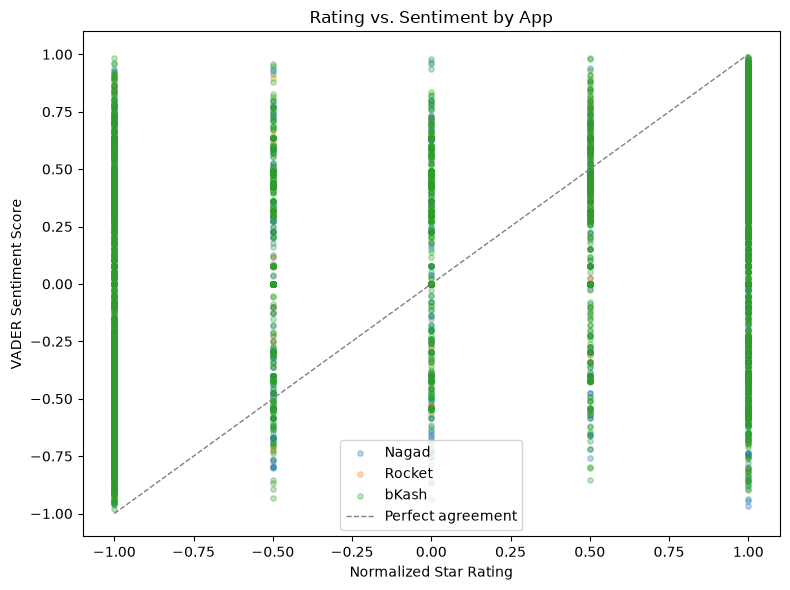

In [36]:
if scored_master_df is not None:
    plot_rating_vs_sentiment(scored_master_df, save_path=str(run_paths["result_dir"] / "scatter_rating_vs_sentiment.png"))

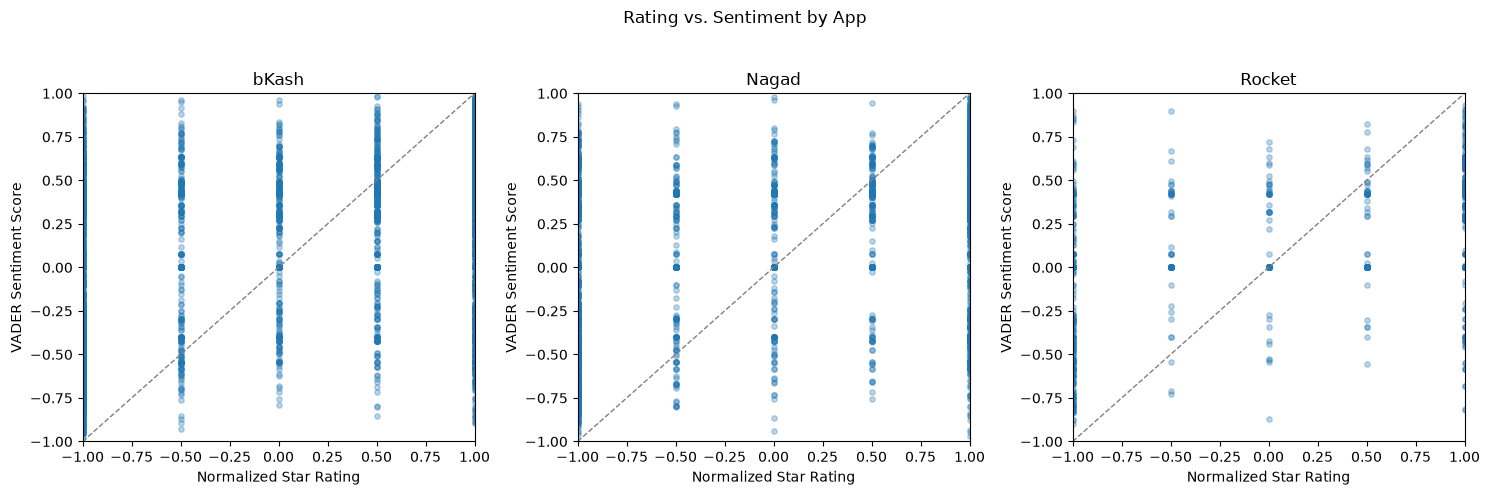

In [37]:
if scored_master_df is not None:
    plot_rating_vs_sentiment_by_app(scored_master_df, save_path=str(run_paths["result_dir"] / "scatter_rating_vs_sentiment_by_app.png"))

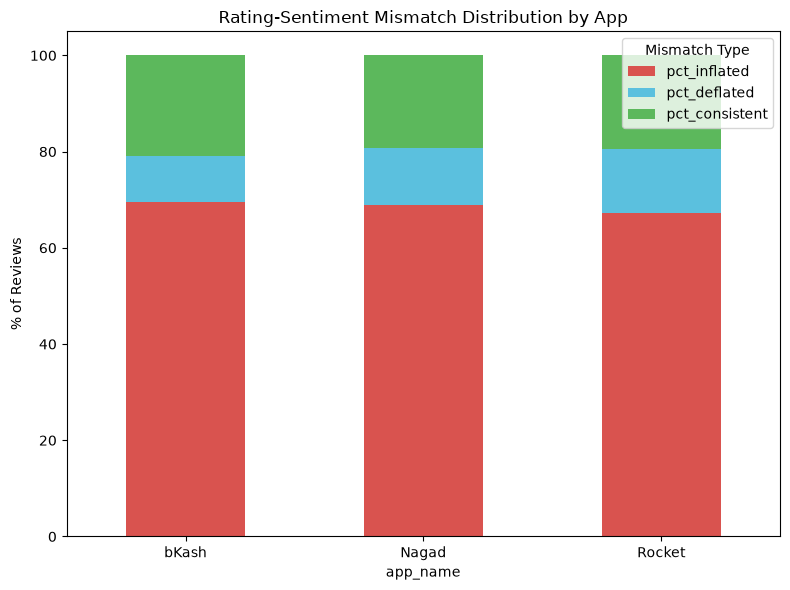

In [38]:
if summary_df is not None:
    plot_mismatch_composition(summary_df, save_path=str(run_paths["result_dir"] / "stacked_bar_mismatch.png"))

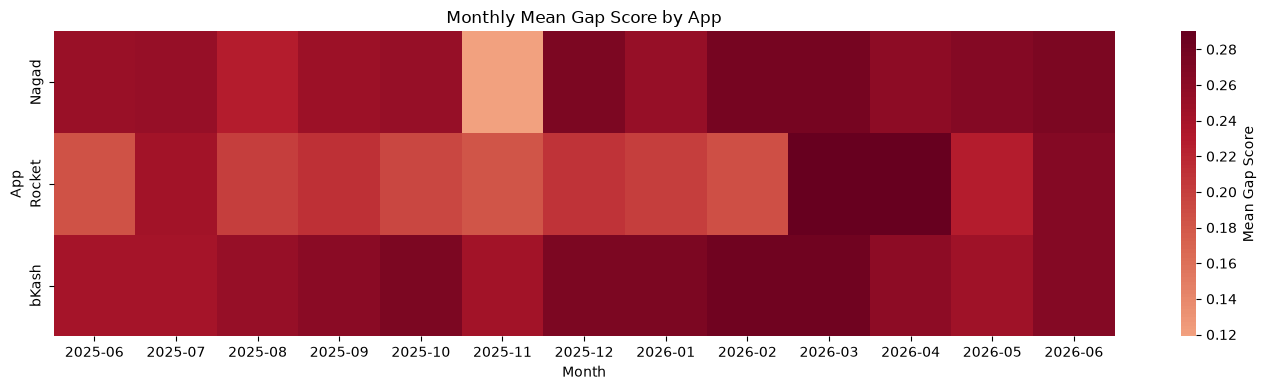

In [39]:
if trend_df is not None:
    plot_monthly_gap_heatmap(trend_df, save_path=str(run_paths["result_dir"] / "monthly_gap_heatmap.png"))

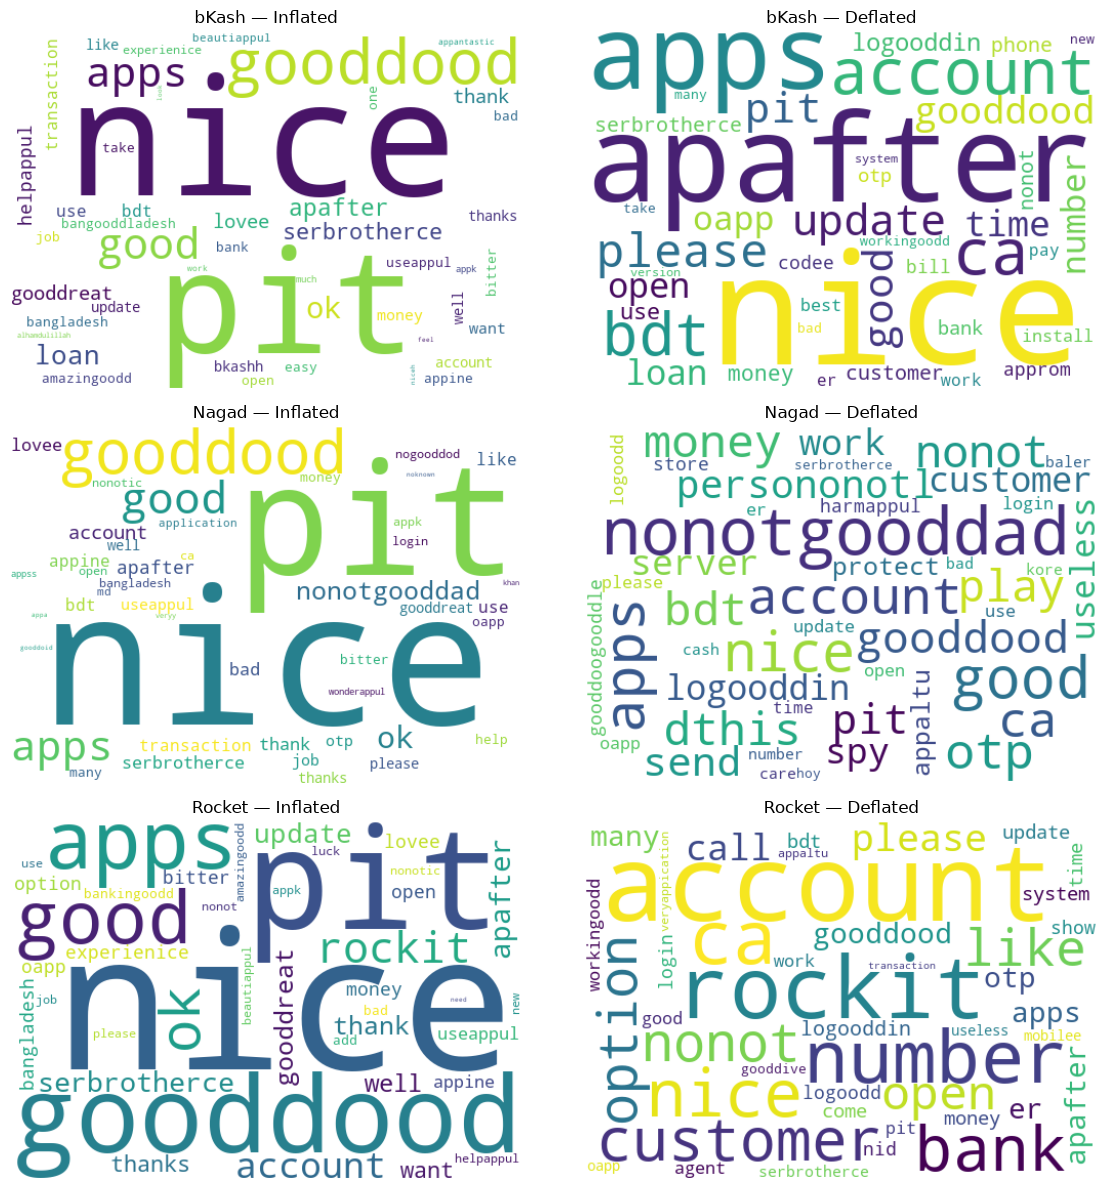

In [40]:
if lda_results is not None:
    plot_lda_wordclouds(lda_results, save_path=str(run_paths["result_dir"] / "wordclouds.png"))

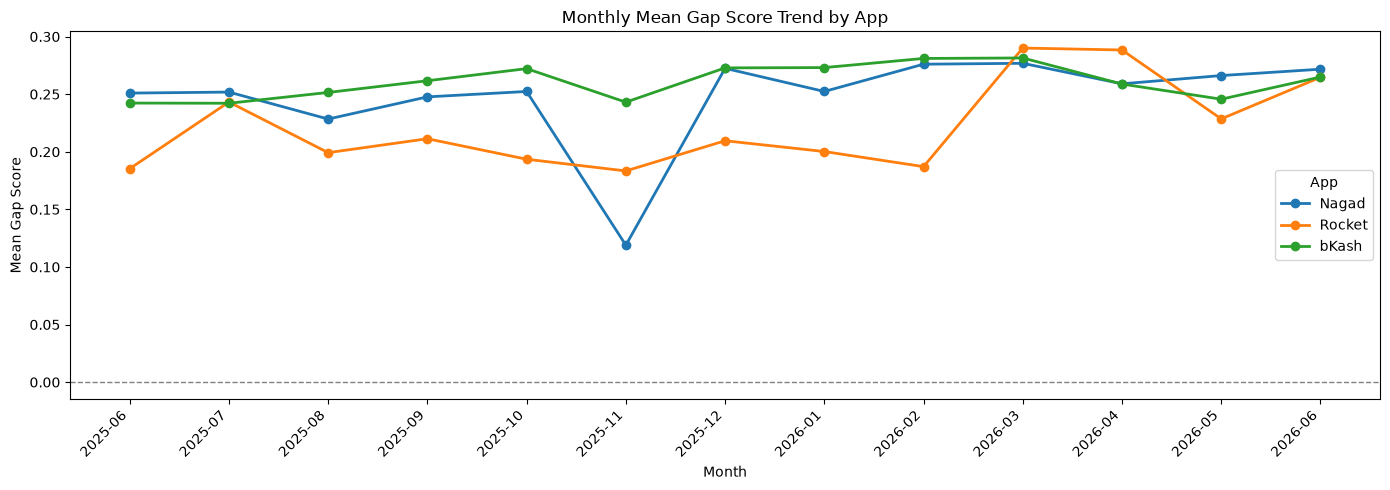

In [41]:
if trend_df is not None:
    plot_monthly_gap_trend(trend_df, save_path=str(run_paths["result_dir"] / "monthly_gap_line_chart.png"))

## Export Sampled Inspection Data

This section generates a consolidated CSV with sampled mismatch reviews and their preprocessing details for manual inspection and debugging.

In [42]:
def export_sampled_mismatches(scored_master_path, run_paths, n_per_label: int = 10):
    """
    Export sampled Inflated and Deflated reviews with their preprocessing details.
    
    Useful for manual inspection and debugging of mismatch classification.
    Merges the scored reviews with their translation/preprocessing details.
    
    Parameters
    ----------
    scored_master_path : Path or str
        Path to the scored master CSV.
    run_paths : dict
        Run paths dictionary (from get_run_paths()).
    n_per_label : int, optional
        Number of samples per mismatch label. Default is 10.
    
    Returns
    -------
    pd.DataFrame
        Consolidated dataframe with sampled mismatches and preprocessing details.
    """
    scored_df = pd.read_csv(scored_master_path)
    
    # Keep only Inflated and Deflated reviews and sample n from each label
    subset = scored_df[scored_df["mismatch_label"].isin(["Inflated", "Deflated"])].copy()
    subset = (
        subset.groupby("mismatch_label", group_keys=False)
        .apply(lambda g: g.sample(n=min(n_per_label, len(g)), random_state=42))
        .reset_index(drop=True)
    )

    # Find translation files that were already produced for this run
    translation_dir = run_paths["translated_dir"]
    translation_paths = []
    if translation_dir.exists():
        translation_paths.extend(sorted(translation_dir.glob("*_translated.csv")))

    translation_frames = []
    for path in translation_paths:
        tmp = pd.read_csv(path)
        if "review_id" in tmp.columns:
            tmp["source_file"] = path.stem
            translation_frames.append(tmp)

    # Merge the sampled score rows with the translation/preprocessing details
    if translation_frames:
        translation_df = pd.concat(translation_frames, ignore_index=True)
        subset = subset.merge(
            translation_df,
            on="review_id",
            how="left",
            suffixes=("", "_translation")
        )
    else:
        subset["source_file"] = None
        subset["original_text"] = None
        subset["pre_translated_text"] = None
        subset["emoji_converted"] = None
        subset["detected_lang"] = None
        subset["confidence"] = None
        subset["translated_text"] = None
        subset["cleaned_text"] = None
        subset["post_translated"] = None

    # Save the consolidated CSV
    output_path = run_paths["result_dir"] / "sampled_inflated_deflated_with_translation.csv"
    subset.to_csv(output_path, index=False)
    return subset


# Export sampled mismatches for inspection
if scored_master_df is not None:
    sampled_df = export_sampled_mismatches(
        run_paths["scored_master_csv_path"],
        run_paths,
        n_per_label=10
    )
    print(f"Exported {len(sampled_df)} sampled mismatches for inspection")
    print(f"Saved to: {run_paths['result_dir'] / 'sampled_inflated_deflated_with_translation.csv'}")
    sampled_df.head()

Exported 20 sampled mismatches for inspection
Saved to: H:\K502_project\results\bangla_english\sampled_inflated_deflated_with_translation.csv
